In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("laptop_battery_life_5000_final.csv")

In [3]:
df.head()
df.shape
df.columns
df.info()
df.isnull().sum()
df.duplicated().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   device_id               5000 non-null   object 
 1   brand                   5000 non-null   object 
 2   os                      5000 non-null   object 
 3   usage_type              5000 non-null   object 
 4   battery_capacity_wh     5000 non-null   float64
 5   cpu_tdp_w               5000 non-null   float64
 6   ram_gb                  5000 non-null   int64  
 7   screen_size_inch        5000 non-null   float64
 8   refresh_rate_hz         5000 non-null   int64  
 9   brightness_percent      5000 non-null   int64  
 10  cpu_usage_percent       5000 non-null   int64  
 11  gpu_usage_percent       5000 non-null   int64  
 12  wifi_on                 5000 non-null   int64  
 13  bluetooth_on            5000 non-null   int64  
 14  temperature_c           5000 non-null   

,battery_capacity_wh,cpu_tdp_w,ram_gb,screen_size_inch,refresh_rate_hz,brightness_percent,cpu_usage_percent,gpu_usage_percent,wifi_on,bluetooth_on,temperature_c,battery_age_months,battery_health_percent,battery_life_hours
count,5000.000000,5000.0000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,55.250980,25.2782,15.929600,14.962080,97.931400,59.808800,52.128200,50.949000,0.919200,0.753400,40.304040,30.069800,91.490100,2.990514
std,14.298447,10.9683,11.598463,1.349257,45.703515,23.438142,27.776841,29.098236,0.272555,0.431075,5.028607,17.687529,5.350647,1.246807
min,30.000000,8.0000,4.000000,11.600000,60.000000,20.000000,5.000000,0.000000,0.000000,0.000000,28.000000,0.000000,75.700000,1.000000
25%,44.700000,16.9000,8.000000,14.000000,60.000000,40.000000,28.000000,26.000000,1.000000,1.000000,36.700000,15.000000,87.300000,2.080000
50%,54.800000,24.8500,16.000000,15.000000,75.000000,60.000000,52.000000,51.000000,1.000000,1.000000,40.300000,30.000000,91.500000,2.790000
75%,64.900000,32.9000,16.000000,16.000000,144.000000,80.000000,77.000000,77.000000,1.000000,1.000000,43.800000,45.000000,95.900000,3.670000
max,100.000000,64.8000,64.000000,17.300000,240.000000,100.000000,100.000000,100.000000,1.000000,1.000000,57.300000,60.000000,100.000000,9.080000


In [4]:
print("Brands:")
print(df["brand"].unique())

print("\nOperating Systems:")
print(df["os"].unique())

print("\nUsage Types:")
print(df["usage_type"].unique())

Brands:
['MSI' 'ASUS' 'Acer' 'Lenovo' 'Dell' 'Apple' 'HP']

Operating Systems:
['Windows' 'Linux' 'macOS']

Usage Types:
['Office' 'Coding' 'Gaming' 'Video' 'Browsing']


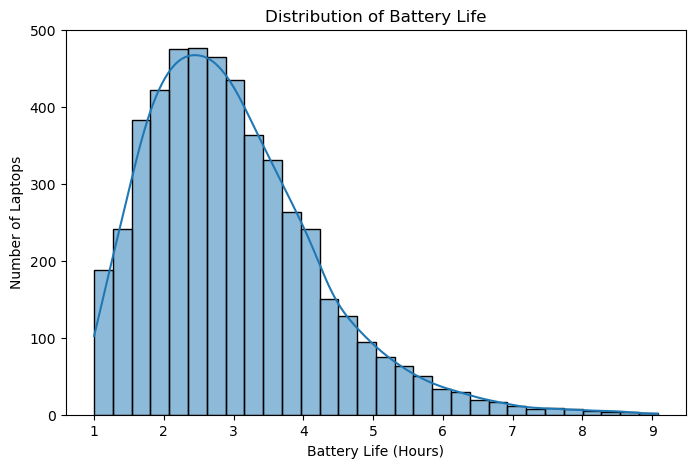

In [5]:
plt.figure(figsize=(8,5))

sns.histplot(df["battery_life_hours"], bins=30, kde=True)

plt.title("Distribution of Battery Life")
plt.xlabel("Battery Life (Hours)")
plt.ylabel("Number of Laptops")

plt.show()

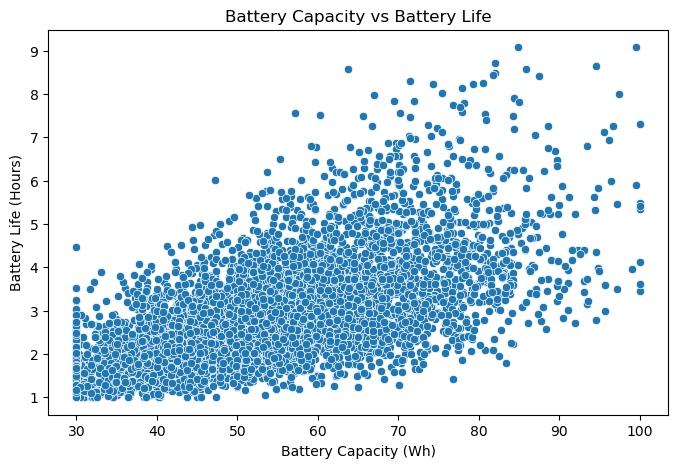

In [6]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="battery_capacity_wh",
    y="battery_life_hours"
)

plt.title("Battery Capacity vs Battery Life")
plt.xlabel("Battery Capacity (Wh)")
plt.ylabel("Battery Life (Hours)")

plt.show()

In [7]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

correlation = numeric_df.corr()

correlation["battery_life_hours"].sort_values(ascending=False)

battery_life_hours        1.000000
battery_capacity_wh       0.609388
battery_health_percent    0.166117
bluetooth_on             -0.018150
ram_gb                   -0.019306
wifi_on                  -0.037846
brightness_percent       -0.038960
screen_size_inch         -0.056810
gpu_usage_percent        -0.116130
battery_age_months       -0.150094
temperature_c            -0.243918
refresh_rate_hz          -0.255189
cpu_usage_percent        -0.306500
cpu_tdp_w                -0.416978
Name: battery_life_hours, dtype: float64

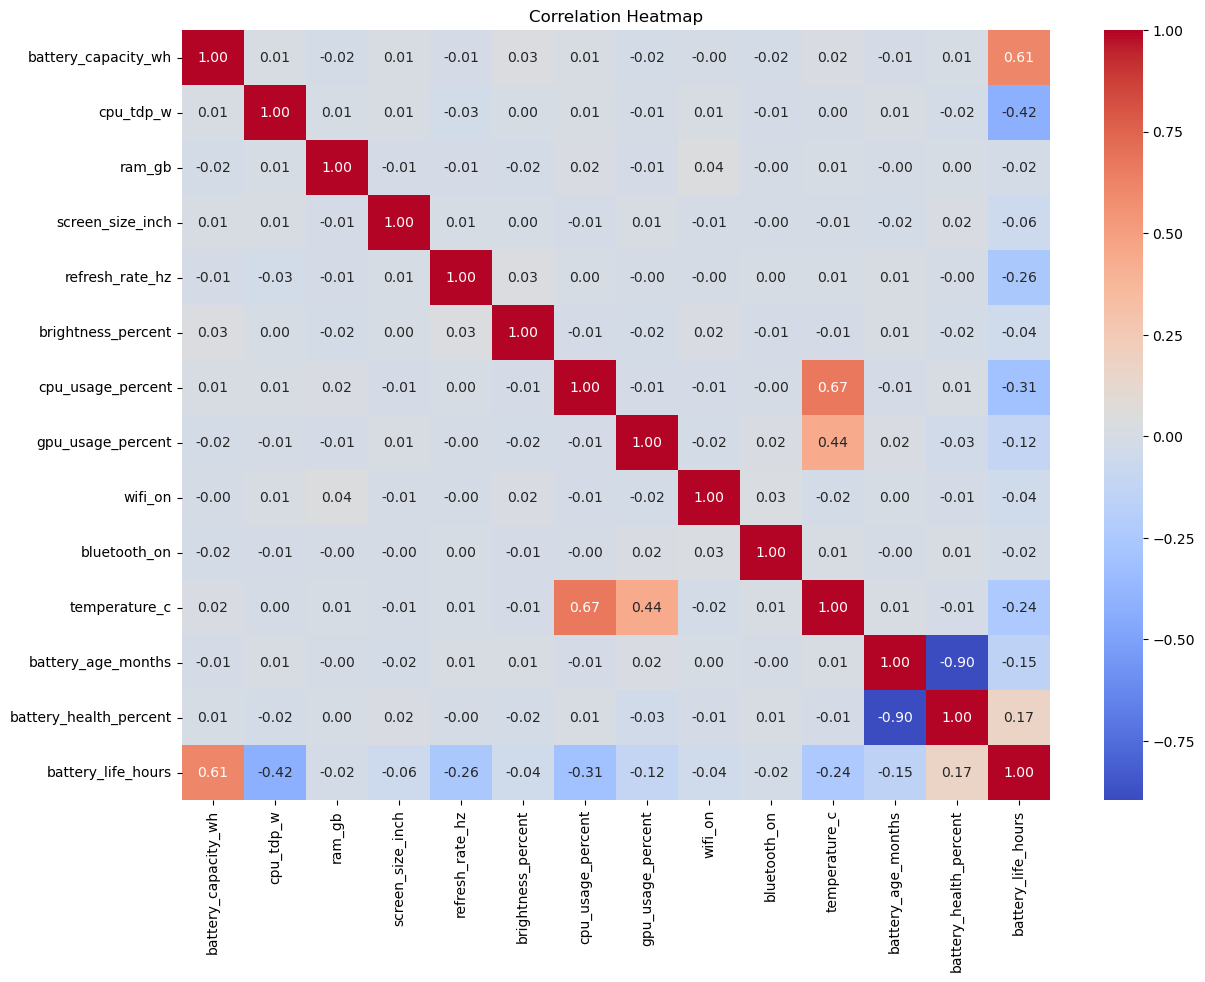

In [8]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

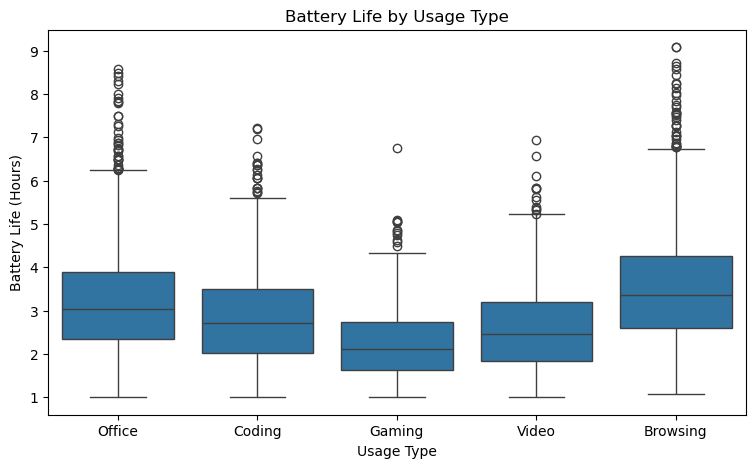

In [9]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="usage_type",
    y="battery_life_hours"
)

plt.title("Battery Life by Usage Type")
plt.xlabel("Usage Type")
plt.ylabel("Battery Life (Hours)")

plt.show()

In [10]:
df.groupby("usage_type")["battery_life_hours"].mean().sort_values(ascending=False)

usage_type
Browsing    3.561946
Office      3.237596
Coding      2.859724
Video       2.578342
Gaming      2.227234
Name: battery_life_hours, dtype: float64

In [11]:
df = df.drop("device_id", axis=1)

In [12]:
df.head()

,brand,os,usage_type,battery_capacity_wh,cpu_tdp_w,ram_gb,screen_size_inch,refresh_rate_hz,brightness_percent,cpu_usage_percent,gpu_usage_percent,wifi_on,bluetooth_on,temperature_c,battery_age_months,battery_health_percent,battery_life_hours
0,MSI,Windows,Office,58.3,25.3,8,15.7,120,58,100,4,1,1,43.8,51,92.4,2.57
1,ASUS,Linux,Office,76.9,33.4,64,15.9,90,99,46,84,1,1,44.0,13,98.1,3.55
2,Acer,Windows,Coding,95.7,54.5,16,13.8,90,60,63,71,1,1,40.9,26,90.9,2.99
3,MSI,Linux,Gaming,31.7,31.6,16,16.9,144,86,40,6,1,0,36.1,20,92.8,1.12
4,Lenovo,Windows,Office,76.3,16.3,16,14.9,165,55,38,38,1,1,39.6,22,96.4,4.04


In [13]:
X = df.drop("battery_life_hours", axis=1)

y = df["battery_life_hours"]

In [14]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5000, 16)
y shape: (5000,)


In [15]:
X = pd.get_dummies(
    X,
    columns=["brand", "os", "usage_type"],
    drop_first=True
)

In [16]:
X.head()

,battery_capacity_wh,cpu_tdp_w,ram_gb,screen_size_inch,refresh_rate_hz,brightness_percent,cpu_usage_percent,gpu_usage_percent,wifi_on,bluetooth_on,...,brand_Dell,brand_HP,brand_Lenovo,brand_MSI,os_Windows,os_macOS,usage_type_Coding,usage_type_Gaming,usage_type_Office,usage_type_Video
0,58.3,25.3,8,15.7,120,58,100,4,1,1,...,False,False,False,True,True,False,False,False,True,False
1,76.9,33.4,64,15.9,90,99,46,84,1,1,...,False,False,False,False,False,False,False,False,True,False
2,95.7,54.5,16,13.8,90,60,63,71,1,1,...,False,False,False,False,True,False,True,False,False,False
3,31.7,31.6,16,16.9,144,86,40,6,1,0,...,False,False,False,True,False,False,False,True,False,False
4,76.3,16.3,16,14.9,165,55,38,38,1,1,...,False,False,True,False,True,False,False,False,True,False


In [17]:
print("New X shape:", X.shape)

New X shape: (5000, 25)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [19]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4000, 25)
X_test: (1000, 25)
y_train: (4000,)
y_test: (1000,)


In [20]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
y_pred_lr = lr_model.predict(X_test)

In [22]:
print("Actual:", y_test.iloc[:10].values)
print("Predicted:", y_pred_lr[:10])

Actual: [6.82 1.9  2.42 2.59 1.2  2.63 2.83 1.64 3.4  2.41]
Predicted: [5.71072966 1.8630827  2.82641575 2.45678407 0.93963351 2.93886544
 2.84702103 1.45701295 3.86976396 2.74091916]


In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)

r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression Results
-------------------------
MAE : 0.28718250573230475
RMSE: 0.38931438569346255
R²  : 0.8949361886068636


In [24]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    max_depth=8,
    random_state=42
)

dt_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [25]:
y_pred_dt = dt_model.predict(X_test)

In [26]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)

rmse_dt = np.sqrt(
    mean_squared_error(y_test, y_pred_dt)
)

r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("---------------------")
print("MAE :", mae_dt)
print("RMSE:", rmse_dt)
print("R²  :", r2_dt)

Decision Tree Results
---------------------
MAE : 0.5139000328191705
RMSE: 0.6900808397623598
R²  : 0.6698949360408079


In [27]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
y_pred_rf = rf_model.predict(X_test)

In [29]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Results
---------------------
MAE : 0.3487648834492688
RMSE: 0.4631240086591203
R²  : 0.8513219558149484


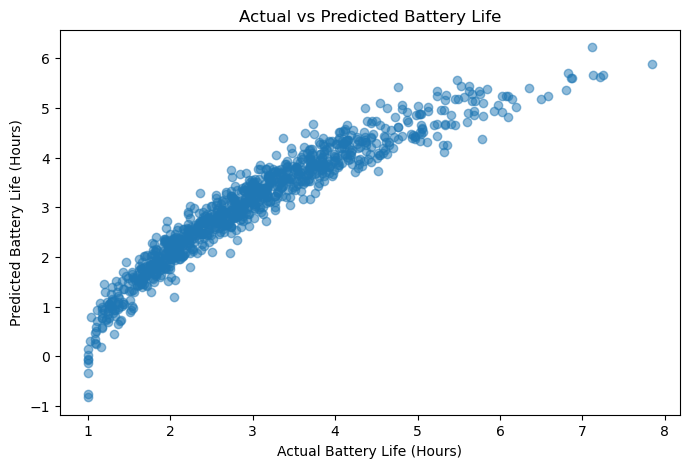

In [30]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_lr, alpha=0.5)

plt.xlabel("Actual Battery Life (Hours)")
plt.ylabel("Predicted Battery Life (Hours)")
plt.title("Actual vs Predicted Battery Life")

plt.show()

In [31]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
})

coefficients["Absolute_Coefficient"] = abs(coefficients["Coefficient"])

coefficients = coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient,Absolute_Coefficient
22,usage_type_Gaming,-1.378895,1.378895
24,usage_type_Video,-0.957621,0.957621
21,usage_type_Coding,-0.695247,0.695247
23,usage_type_Office,-0.373130,0.373130
8,wifi_on,-0.199560,0.199560
15,brand_Dell,0.058251,0.058251
9,bluetooth_on,-0.055147,0.055147
0,battery_capacity_wh,0.054016,0.054016
3,screen_size_inch,-0.052064,0.052064
13,brand_Acer,0.051297,0.051297


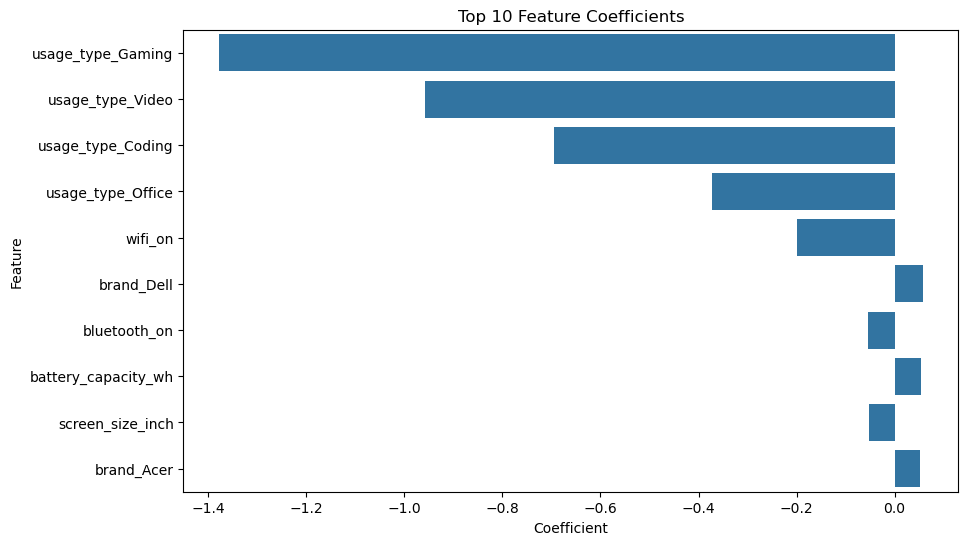

In [32]:
top_features = coefficients.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Coefficient",
    y="Feature"
)

plt.title("Top 10 Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

In [33]:
import joblib

joblib.dump(lr_model, "battery_life_model.pkl")

['battery_life_model.pkl']

In [34]:
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']

In [35]:
%pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [39]:
#import streamlit as st
#import pandas as pd
#import joblib

# Load model
#model = joblib.load("battery_life_model.pkl")

# Load feature columns
#feature_columns = joblib.load("feature_columns.pkl")

# Page configuration
#st.set_page_config(
    #page_title="Laptop Battery Life Predictor",
    #page_icon="🔋",
    #layout="wide"
#)

# Title
#st.title("🔋 Laptop Battery Life Predictor")
#st.write("Predict laptop battery backup using Machine Learning.")

#st.divider()